<a href="https://www.kaggle.com/code/jatin2055/langgraph-rag?scriptVersionId=267708055" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1133]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1134]:
from typing import TypedDict, Literal, Annotated, List

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage, BaseMessage
from langchain_core.prompts import ChatPromptTemplate, HumanMessagePromptTemplate
from langchain_community.document_loaders import WebBaseLoader, PyPDFLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings
from langchain_pinecone import Pinecone, PineconeVectorStore
from langchain_tavily import TavilySearch
from langchain.docstore.document import Document
from langchain_core.output_parsers.string import StrOutputParser

from langgraph.graph import START, END, StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import create_react_agent


from pydantic import BaseModel, Field

from pinecone import Pinecone, ServerlessSpec

# CONSTANTS

In [1135]:
pinecone_api_key = 'api_key'
api_key='api_key'
tavily_api = 'api_key'


In [1136]:
import os

langsmith = 'api_key'

os.environ["LANGCHAIN_API_KEY"] = langsmith
os.environ["LANGCHAIN_TRACING_V2"]="true"
os.environ["LANGCHAIN_PROJECT"]="LangGraph RAG | Pinecone"

os.environ['LANGCHAIN_ENDPOINT'] = 'https://api.smith.langchain.com'


In [1137]:
text_urls = [
    'https://lilianweng.github.io/posts/2020-10-29-odqa/',
    'https://lilianweng.github.io/posts/2024-07-07-hallucination/',
    'https://lilianweng.github.io/posts/2023-06-23-agent/',
    'https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/',
    'https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/'
]

# Models

# embedding model - other than the embedding model selected when creating pinecone index

In [1138]:
embeddings_model = OpenAIEmbeddings(
    model="text-embedding-3-large",
    api_key=api_key,
    dimensions=1024 
)



# grading model

In [1139]:
grading_llm = ChatOpenAI(api_key=api_key)
generative_llm = ChatOpenAI(model_name="gpt-4-turbo", temperature=0.5, api_key=api_key)

In [1140]:
tavily_search_tool = TavilySearch(
    tavily_api_key = tavily_api,
    max_results = 3)


# One Time - Loading Documents

# _fetching from the URL

In [1141]:

# def retrieve_documents(urls):
    
#     documents = []
    
#     for url in urls:
        
#         wb_load = WebBaseLoader(url)
#         document = wb_load.load()
#         documents.extend(document)

#     return documents


In [1142]:
# text_documents = retrieve_documents(text_urls)

# _chunking the docs

In [1143]:
import time

current_timestamp = str(int(time.time()))
print(current_timestamp)

1760342675


In [1144]:
# def split_text(documents):
    
#     text_splitter = RecursiveCharacterTextSplitter(
#         chunk_size=300,
#         chunk_overlap=50
#     )
    
#     return text_splitter.split_documents(documents)


In [1145]:
# text_splitted_documents = split_text(text_documents)
# documents = [doc for id, doc in enumerate(text_splitted_documents)]
# ids = [ current_timestamp+'_'+ str(id) for id, doc in enumerate(text_splitted_documents)]


# Vector DB - Embeddings Ingestion

In [1146]:
pc = Pinecone(api_key=pinecone_api_key)
pc_namespace = 'langGraph-RAG'
index_name = "langraph-based-index"


In [1147]:

# ONE TIME FOR INDEX CREATION - Create a dense index with integrated inference
# pc.create_index_for_model(
#     name=index_name,
#     cloud="aws",
#     region="us-east-1",
#     embed={
#         "model": "multilingual-e5-large",
#         "field_map": {
#             "text": "text"  # Map the record field to be embedded
#         }
#     }
# )

# existing_indexes = [index_info["name"] for index_info in pc.list_indexes()]

# if index_name not in existing_indexes:

#     pc.create_index(
#         name=index_name,
#         dimension=1024,
#         metric="cosine",
#         spec=ServerlessSpec(cloud="aws", region="us-east-1"),
#     )

index = pc.Index(index_name)
vector_store = PineconeVectorStore(index=index, embedding=embeddings_model)

In [1148]:
def add_document(documents, ids):

    vector_store.add_documents(documents=documents, ids=ids)

In [1149]:
#add_document(documents, ids)

In [1150]:
#documents[4]

In [1151]:
def pinecone_retriever():

    return vector_store.as_retriever(
        search_type="mmr",
        search_kwargs={"k": 3, "fetch_k": 10, "lambda_mult": 0.7},
    )

retriever = pinecone_retriever()

# States

In [1175]:
class RAGState(TypedDict):
    
    question: str
    final_output: str
    web_search: bool
    web_search_results: str
    documents: List[str]
    has_hallucinated: bool

In [1176]:
class GradingState(BaseModel):

    are_document_relevant: bool = Field(..., decsription="To decide whether the documents are relevant for the query or not")

In [1177]:
class GradeHallucination(BaseModel):

    is_answer_hallucinated: bool = Field(..., description="To determine whether the final response is per the question raised or the llm has hallucinated.")

# Functions

In [1178]:
def retrieve(state: RAGState):

    question = state['question']

    documents = retriever.invoke(question)

    return {"documents": documents, "question": question}

In [1179]:
def web_search(state: RAGState):

    
    tavily_results  = web_search_tool.invoke({"query": state["question"]}) 


    web_results = Document(page_content=str(tavily_results["results"]))

    documents = state["documents"]
    
    if documents is None:
        documents = [web_results]
    else:
        documents.append(web_results)
        
    return {"documents": documents}

In [1180]:
def generate(state: RAGState):

    system_prompt = """Generate a summarised result query asked based on the documents provided by the user. """    
    human_prompt = "question: {question} \n\n documents: {documents} "

    generative_prompt_template = ChatPromptTemplate.from_messages([
        ("system", system_prompt),
        ("human", human_prompt)
    ])

    parser = StrOutputParser()

    generative_chain = generative_prompt_template | generative_llm | parser

    final_response = generative_chain.invoke({
        "question": state["question"],
        "documents": str(state["documents"]),
    })
    
    print(final_response)

    return {"final_output": final_response}

In [1181]:
def document_evaluation(state: RAGState):

    return "web_search" if state["web_search"] else "generate"
     

In [1182]:
def grade_documents(state: RAGState):

    system_prompt = """
        You are an expert relevance checker for a RAG system.

        Your task is to decide if the provided set of **Document** contains information directly relevant and sufficient to answer the **User Query**.
        
        Available Document Title (Knowledge Base Focus):
        1. LLM Powered Autonomous Agents
        2. Prompt Engineering - Zero-Shot, Few-Shot, etc.
        3. Adversarial Attacks on LLMs - Threat Model, Token Manipulation, etc.
        4. How to Build an Open-Domain Question Answering System? - Open-book QA: Retriever-Reader
        5. Extrinsic Hallucinations in LLMs - Pre-training Data Issues, Fine-tuning New Knowledge, etc.
        
        User Query contains documents and the query
        
        **Decision Rules:**
        * Respond **True** if the User Query falls directly and entirely within the scope of the available Document Titles (i.e., it's about agents, prompt engineering, adversarial attacks, QA systems, or extrinsic hallucinations).
        * Respond **False** For any other query not specific to or in the titles/scope of  "Available Document Title", then respond back as False.
        
        **Output Format:**
        A single boolean value (`True` or `False`) and nothing else.
        
        **Decision:**
    
    """

    user_query = "documents: {documents} \n\n query: {query}" 

 
    messages = [
        SystemMessage(
            content=system_prompt
        ),
        # HumanMessage(  --- This code is't working. ANY GUESSES?
        #     content="documents: {documents} \n\n query: {query}" 
        # ),
        ("human",  "documents: {documents} \n\n query: {query}")
        
       #OR USE THIS FORMAT HumanMessagePromptTemplate.from_template(user_query)
    ]

    grading_prompt = ChatPromptTemplate.from_messages(messages)


    grade_chaining = grading_prompt | grading_llm.with_structured_output(GradingState)

    response = grade_chaining.invoke({
        "documents": state["documents"],
        "query": state["question"]
    })

    web_search = True if response.are_document_relevant == False else False

    return {"web_search": web_search }

In [1187]:
def check_hallucination(state: RAGState):

    system_prompt = """ You are a grader assessing wether the LLM generation (final_output) is grounded in  or supported by the question raised by the user and set of documents shared.
        If the response is as per and in the context of the question and the attached documents raised respond back with True, else return False
    """

    hallucinated_prompt = ChatPromptTemplate.from_messages([
        ("system", system_prompt),
        ("human", "Set of Facts: documents: {documents}, question: {question}, final_output: {final_output} ")
    ])
 
    hallucination_chain = hallucinated_prompt | grading_llm.with_structured_output(GradeHallucination)

    response = hallucination_chain.invoke({
        "question": state["question"],
        "documents": state["documents"],
        "final_output": state["final_output"],
    })

    print(response)

    return {"has_hallucinated": not response}

# BUILDING GRAPH

In [1188]:
builder = StateGraph(RAGState)

builder.add_node("retrieve", retrieve)
builder.add_node("grade_documents", grade_documents)
builder.add_node("web_search", web_search)
builder.add_node("generate", generate)
builder.add_node("check_hallucination", check_hallucination)

builder.add_edge(START, "retrieve")
builder.add_edge("retrieve", "grade_documents")
builder.add_edge("web_search", "generate")
builder.add_edge("generate", "check_hallucination")
builder.add_edge("check_hallucination", END)

builder.add_conditional_edges("grade_documents", document_evaluation, {"web_search": "web_search", "generate": "generate"})


workspace = builder.compile()

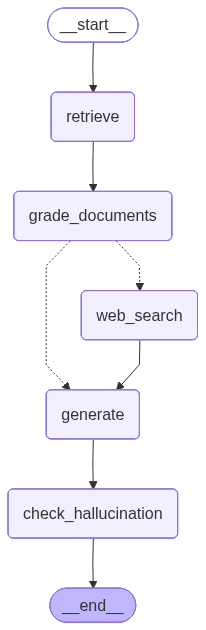

In [1189]:
workspace

In [1199]:
output = workspace.invoke({"question": "Who is the president united republic of kambala"})


/usr/local/lib/python3.11/dist-packages/langchain_openai/chat_models/base.py:1949: UserWarning: Cannot use method='json_schema' with model gpt-3.5-turbo since it doesn't support OpenAI's Structured Output API. You can see supported models here: https://platform.openai.com/docs/guides/structured-outputs#supported-models. To fix this warning, set `method='function_calling'. Overriding to method='function_calling'.
  warnings.warn(


The president of the United Republic of Kambala is not explicitly mentioned in the provided documents. The documents contain information on various topics, including large language models, autonomous agent systems, and historical figures from Tanzania, but there is no direct reference to the current president of the United Republic of Kambala.


/usr/local/lib/python3.11/dist-packages/langchain_openai/chat_models/base.py:1949: UserWarning: Cannot use method='json_schema' with model gpt-3.5-turbo since it doesn't support OpenAI's Structured Output API. You can see supported models here: https://platform.openai.com/docs/guides/structured-outputs#supported-models. To fix this warning, set `method='function_calling'. Overriding to method='function_calling'.
  warnings.warn(


is_answer_hallucinated=False


In [1200]:
res = input("Hello")

Hello yes


In [1201]:
print(res)

yes


In [1196]:
#print(output)
for items in output:
    print(items)
    print(output[items])
    print("==========================")

question
Date of origin of Godzilla
final_output
Godzilla originated from the 1954 film directed and co-written by Ishirō Honda. The character debuted in this eponymous film released on October 27th, 1954.
web_search
True
documents
[Document(metadata={'description': 'The use of large language models in the real world has strongly accelerated by the launch of ChatGPT. We (including my team at OpenAI, shoutout to them) have invested a lot of effort to build default safe behavior into the model during the alignment process (e.g. via RLHF). However, adversarial attacks or jailbreak prompts could potentially trigger the model to output something undesired.\nA large body of ground work on adversarial attacks is on images, and differently it operates in the continuous, high-dimensional space. Attacks for discrete data like text have been considered to be a lot more challenging, due to lack of direct gradient signals. My past post on Controllable Text Generation is quite relevant to this topic